In [5]:
# --- Cell 1: imports + config ---
%load_ext autoreload
%autoreload 2
import sys, torch, numpy as np
sys.path.append('..')
sys.path.append('../..')

from common.seed import set_seed
from common.io_utils import save_results, load_results
from shared.pacs_protocol import build_loaders, next_source_batch
from task2.backbones.backbone import PACSModel, set_train_mode
from task2.training.train_loop import train_model
from task2.methods.cdan import CDAN

set_seed(6304)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CFG = dict(seed=6304, num_classes=7,
           batch_per_source=8, target_batch=24, eval_batch=64, num_workers=0,
           max_epochs=30, patience=5, lr=1e-4, weight_decay=1e-4,
           amp=False,
           feat_dim=512, disc_hidden=256,
           alpha_max=1.0,                    
           lambda_domain=1.0,
           normalize_disc_input=False)
DATA_ROOT = '../../datasets/PACS'
print(CFG['alpha_max'], CFG['normalize_disc_input'])   

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
1.0 False


In [6]:
# --- Cell 2: loaders ---
splits = load_results('../../shared/splits/pacs_sketch_seed6304.json')
loaders = build_loaders(DATA_ROOT, splits,
                        batch_per_source=CFG['batch_per_source'],
                        target_batch=CFG['target_batch'],
                        eval_batch=CFG['eval_batch'],
                        num_workers=CFG['num_workers'], seed=CFG['seed'])
print(f"steps/epoch={loaders['steps_per_epoch']}")

steps/epoch=203


In [3]:
# --- Cell 3: VERIFICATION---
f = torch.tensor([[1.0, 2.0, 3.0]])                 # 3-d "feature"
p = torch.tensor([[0.9, 0.1, 0.0, 0.0]])            # confident class 0 of 4
g = torch.bmm(f.unsqueeze(2), p.unsqueeze(1)).flatten(1)
print('shape:', tuple(g.shape), '(expect 1 x 12)')
print(g.view(3, 4))
# Each ROW is the feature entry times the probability vector. Reading COLUMNS:
# column 0 = 0.9 * f (the confident class carries the feature),
# columns 2-3 = zeros (classes with no probability mass contribute nothing).

# and on the real shapes
fb = torch.randn(48, 512); pb = torch.softmax(torch.randn(48, 7), dim=1)
gb = torch.bmm(fb.unsqueeze(2), pb.unsqueeze(1)).flatten(1)
print('\nbatch g shape:', tuple(gb.shape), '(expect 48 x 3584)')
print('disc input dim needed:', 512 * 7)

shape: (1, 12) (expect 1 x 12)
tensor([[0.9000, 0.1000, 0.0000, 0.0000],
        [1.8000, 0.2000, 0.0000, 0.0000],
        [2.7000, 0.3000, 0.0000, 0.0000]])

batch g shape: (48, 3584) (expect 48 x 3584)
disc input dim needed: 3584


In [4]:
# --- Cell 3b: DIAGNOSTIC — 400 steps before committing (same as DANN's) ---
set_seed(6304)
probe = PACSModel(num_classes=7).to(device)
pm = CDAN(CFG).to(device)
params = list(probe.parameters()) + list(pm.parameters())
opt = torch.optim.AdamW(params, lr=CFG['lr'], weight_decay=CFG['weight_decay'])
set_train_mode(probe); pm.disc.train()

total = loaders['steps_per_epoch'] * CFG['max_epochs']
for step in range(400):
    sx, sy = next_source_batch(loaders['source_train'], device)
    tx, _ = loaders['target_train'].next(); tx = tx.to(device)
    opt.zero_grad(set_to_none=True)
    loss, logs = pm.compute_loss(probe, sx, sy, tx, step / (total - 1))
    loss.backward()
    gn = torch.nn.utils.clip_grad_norm_(params, float('inf')).item()   # measure only
    opt.step()
    if step % 25 == 0:
        with torch.no_grad():
            fnorm = probe(sx)[1].norm(dim=1).mean().item()
        print(f"step {step:3d}  cls={logs['loss_cls']:.3f}  dom={logs['loss_dom']:.3f}  "
              f"d_acc={logs['domain_acc']:.3f}  tgt_conf={logs['tgt_conf']:.3f}  "
              f"|f|={fnorm:6.1f}  gnorm={gn:7.1f}")

del probe, pm, opt; torch.cuda.empty_cache()

step   0  cls=2.417  dom=0.706  d_acc=0.292  tgt_conf=0.224  |f|=  21.4  gnorm=   15.6
step  25  cls=1.295  dom=0.271  d_acc=0.938  tgt_conf=0.500  |f|=  50.6  gnorm=   25.9
step  50  cls=0.346  dom=0.190  d_acc=0.958  tgt_conf=0.536  |f|=  51.4  gnorm=    8.9
step  75  cls=0.240  dom=0.301  d_acc=0.938  tgt_conf=0.481  |f|=  52.3  gnorm=    6.6
step 100  cls=0.341  dom=0.433  d_acc=0.875  tgt_conf=0.591  |f|=  47.6  gnorm=    9.9
step 125  cls=0.081  dom=0.477  d_acc=0.771  tgt_conf=0.792  |f|=  64.4  gnorm=    5.2
step 150  cls=0.345  dom=0.703  d_acc=0.583  tgt_conf=0.715  |f|=  61.6  gnorm=   13.4
step 175  cls=0.466  dom=0.889  d_acc=0.479  tgt_conf=0.787  |f|=  58.4  gnorm=   16.9
step 200  cls=0.140  dom=0.755  d_acc=0.729  tgt_conf=0.844  |f|=  55.1  gnorm=    6.5
step 225  cls=0.380  dom=0.500  d_acc=0.688  tgt_conf=0.880  |f|=  65.7  gnorm=   15.4
step 250  cls=0.136  dom=0.422  d_acc=0.771  tgt_conf=0.828  |f|=  64.3  gnorm=    7.7
step 275  cls=0.046  dom=0.520  d_acc=0.729

In [7]:
# --- Cell 4: train CDAN ---
set_seed(6304)
loaders = build_loaders(DATA_ROOT, splits,
                        batch_per_source=CFG['batch_per_source'],
                        target_batch=CFG['target_batch'],
                        eval_batch=CFG['eval_batch'],
                        num_workers=CFG['num_workers'], seed=CFG['seed'])
model = PACSModel(num_classes=CFG['num_classes']).to(device)
method = CDAN(CFG).to(device)

out = train_model(model, method, loaders, CFG, device,
                  ckpt_path='../../datasets/cache/task2_cdan.pt')
print(out['best_epoch'], out['best_mean_macro_f1'], f"{out['minutes']:.1f} min")

ep01 loss_total=1.0388 loss_cls=0.5414 loss_dom=0.4974 domain_acc=0.7816 alpha=0.0826 tgt_conf=0.6409 train_acc=0.8155 | val photo=0.927 art_painting=0.836 cartoon=0.901 mean_f1=0.8880 | 39s
ep02 loss_total=0.8091 loss_cls=0.2380 loss_dom=0.5712 domain_acc=0.7036 alpha=0.2440 tgt_conf=0.8166 train_acc=0.9158 | val photo=0.962 art_painting=0.867 cartoon=0.924 mean_f1=0.9176 | 80s
ep03 loss_total=18.7106 loss_cls=4.8969 loss_dom=13.8137 domain_acc=0.5385 alpha=0.3931 tgt_conf=0.5681 train_acc=0.4725 | val photo=0.062 art_painting=0.077 cartoon=0.102 mean_f1=0.0803 | 124s
ep04 loss_total=2.6169 loss_cls=1.9301 loss_dom=0.6868 domain_acc=0.5556 alpha=0.5240 tgt_conf=0.2081 train_acc=0.2108 | val photo=0.059 art_painting=0.051 cartoon=0.042 mean_f1=0.0507 | 169s
ep05 loss_total=2.6032 loss_cls=1.9141 loss_dom=0.6890 domain_acc=0.5416 alpha=0.6341 tgt_conf=0.2140 train_acc=0.2106 | val photo=0.059 art_painting=0.051 cartoon=0.042 mean_f1=0.0507 | 213s
ep06 loss_total=2.5971 loss_cls=1.9036 l

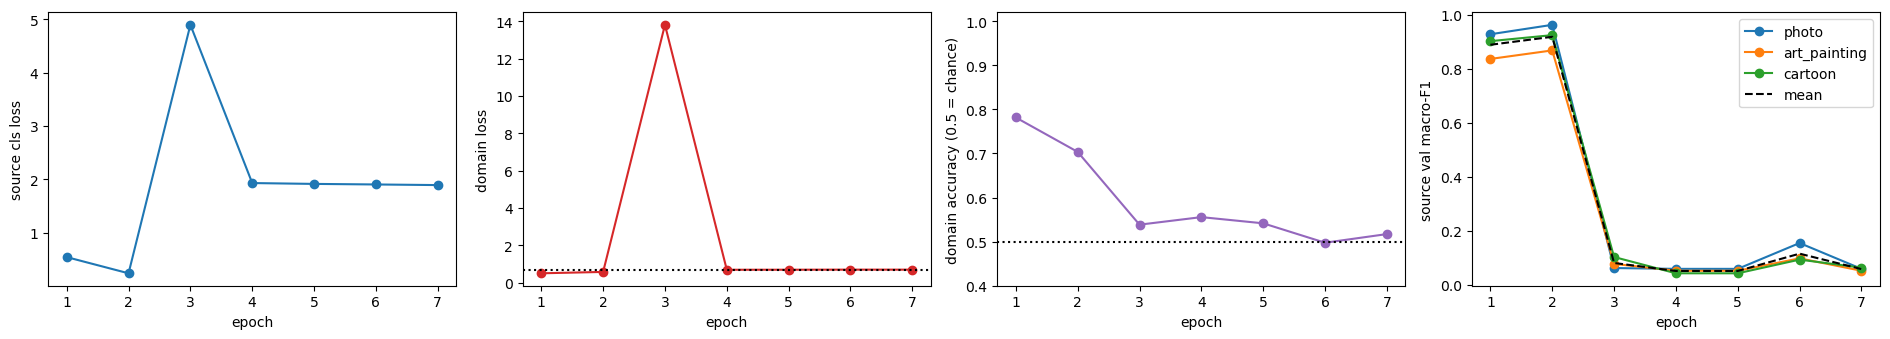

In [8]:
# --- Cell 5: save + curves ---
results = {'step': 'cdan', 'seed': 6304, 'method': 'cdan',
           'config': CFG, 'steps_per_epoch': loaders['steps_per_epoch'],
           'best_epoch': out['best_epoch'],
           'best_mean_macro_f1': out['best_mean_macro_f1'],
           'source_val_at_best': out['source_val_at_best'],
           'minutes': out['minutes'], 'history': out['history']}
save_results(results, '../results/cdan.json')

import matplotlib.pyplot as plt
h = out['history']; ep = [r['epoch'] for r in h]
fig, ax = plt.subplots(1, 4, figsize=(19, 3.5))
ax[0].plot(ep, [r['loss_cls'] for r in h], marker='o'); ax[0].set_ylabel('source cls loss')
ax[1].plot(ep, [r['loss_dom'] for r in h], marker='o', color='tab:red')
ax[1].axhline(np.log(2), ls=':', c='k'); ax[1].set_ylabel('domain loss')
ax[2].plot(ep, [r['domain_acc'] for r in h], marker='o', color='tab:purple')
ax[2].axhline(0.5, ls=':', c='k'); ax[2].set_ylim(0.4, 1.02)
ax[2].set_ylabel('domain accuracy (0.5 = chance)')
for d_ in splits['source_domains']:
    ax[3].plot(ep, [r['per_domain'][d_]['macro_f1'] for r in h], marker='o', label=d_)
ax[3].plot(ep, [r['mean_macro_f1'] for r in h], 'k--', label='mean')
ax[3].set_ylabel('source val macro-F1'); ax[3].legend()
for a_ in ax: a_.set_xlabel('epoch')
plt.tight_layout(); plt.savefig('../../report/figures/task2_cdan_curves.png', dpi=200)
plt.show()